## Descrição
Nessa etapa de análise, a tabela completa é explorada para responder a perguntas sobre as parcelas que compõem o indicador OEE (disponibilidade, performance e qualidade) das ilhas, como por exemplo:
- Quais os indicadores de cada ilha da base 1 em novembro de 2025

Também é gerado um gráfico que mostra a performance das ilhas da base 1 em novembro. Nele é possível identificar as ilhas com mais e menos performance.

In [0]:
spark.sql("USE CATALOG mvp")
spark.sql("USE SCHEMA gold") 

DataFrame[]

In [0]:
%sql
SELECT *
FROM ind_prod_ilha_completa
LIMIT 10

NomeBase,NomeIlha,IdBase,Data,IdIlha,TempoProducaoReal,TempoProducaoPlan,QuantProducaoReal,QuantProducaoPlan,QuantProducaoRuim,QuantProducaoBoa
Base 1,Ilha 1,1,2025-11-01,50121,26513.0,57600.0,383117.0,1740000.0,0.0,65.0
Base 1,Ilha 9,1,2025-11-01,501213,9483.0,57600.0,122347.0,870000.0,10.0,13.0
Base 1,Ilha 8,1,2025-11-01,501219,6319.0,57600.0,82999.0,870000.0,0.0,16.0
Base 1,Ilha 2,1,2025-11-01,50122,22583.0,57600.0,340031.0,1740000.0,0.0,58.0
Base 1,Ilha 3,1,2025-11-01,50123,25494.0,57600.0,444020.0,1740000.0,0.0,91.0
Base 1,Ilha 4,1,2025-11-01,50124,25462.0,57600.0,441043.0,1740000.0,0.0,91.0
Base 1,Ilha 5,1,2025-11-01,50125,29855.0,57600.0,463091.0,1740000.0,0.0,96.0
Base 1,Ilha 6,1,2025-11-01,50126,23201.0,57600.0,392061.0,3060000.0,0.0,78.0
Base 1,Ilha 1,1,2025-11-03,50121,36095.0,57600.0,521125.0,1740000.0,1.0,96.0
Base 1,Ilha 9,1,2025-11-03,501213,4417.0,57600.0,60002.0,870000.0,0.0,12.0


In [0]:
%sql
-- Qual foi o indicador de disponibilidade, performance, qualidade e OEE das ilhas da base 1 no mês de janeiro de 2025
SELECT 
  ind.NomeBase,
  ind.NomeIlha,
  ROUND(SUM(ind.TempoProducaoReal) / SUM(ind.TempoProducaoPlan),2) AS disponibilidade,
  ROUND(SUM(ind.QuantProducaoReal ) / SUM(ind.QuantProducaoPlan ),2) AS performance,
  ROUND(SUM(ind.QuantProducaoBoa ) / SUM((ind.QuantProducaoRuim ) + (ind.QuantProducaoBoa )),2) AS qualidade,
  ROUND((disponibilidade * performance * qualidade),2) AS oee
FROM ind_prod_ilha_completa AS ind
WHERE ind.IdBase = 1
  AND CAST(ind.Data As DATE) BETWEEN CAST('2025-11-01' As DATE) AND CAST('2025-11-30' As DATE)
GROUP BY ind.NomeBase, ind.NomeIlha

NomeBase,NomeIlha,disponibilidade,performance,qualidade,oee
Base 1,Ilha 1,0.55,0.26,0.99,0.14
Base 1,Ilha 9,0.1,0.08,0.93,0.01
Base 1,Ilha 8,0.13,0.1,1.0,0.01
Base 1,Ilha 2,0.51,0.25,1.0,0.13
Base 1,Ilha 3,0.56,0.3,1.0,0.17
Base 1,Ilha 4,0.59,0.31,1.0,0.18
Base 1,Ilha 5,0.59,0.32,1.0,0.19
Base 1,Ilha 6,0.44,0.14,1.0,0.06
Base 1,Ilha 17,0.09,0.07,0.98,0.01
Base 1,Ilha 16,0.09,0.06,0.99,0.01


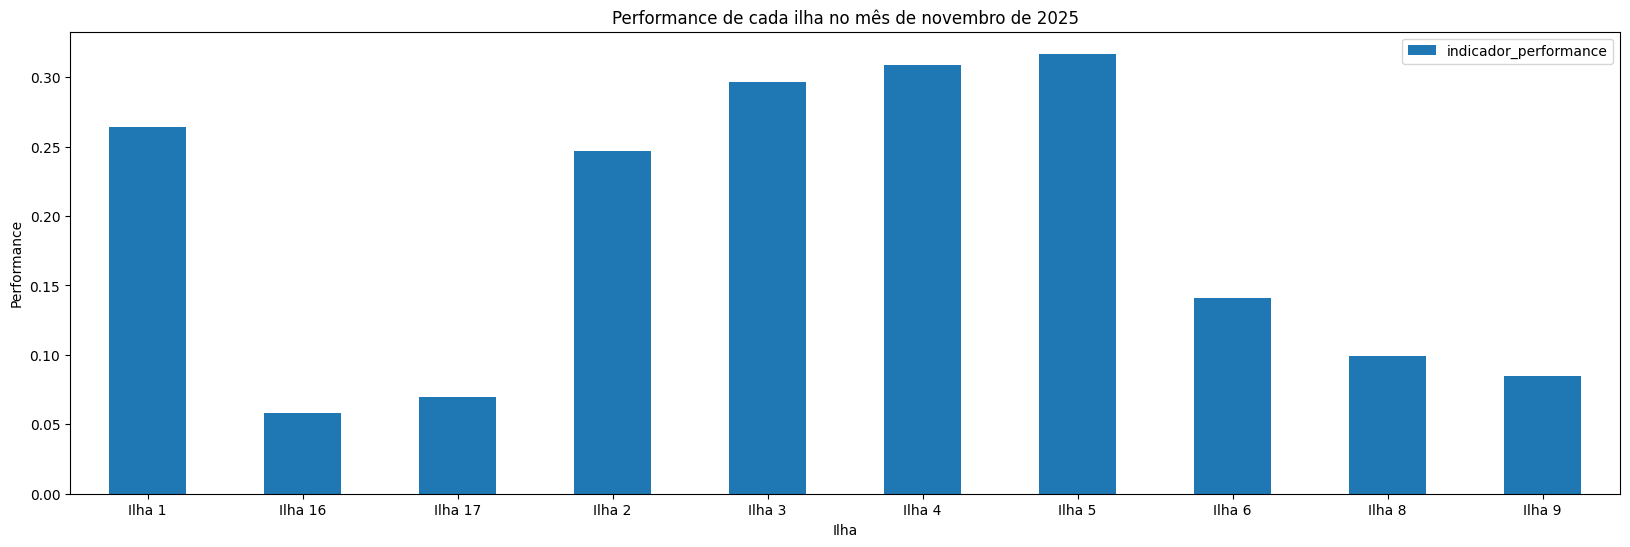

In [0]:
# Usar a bilioteca pandas pra gerar um gráfico de barras contendo a performance de cada ilha no mês de novembro de 2025
import pandas as pd
import matplotlib.pyplot as plt
df = spark.sql("SELECT NomeIlha, (SUM(ind.QuantProducaoReal ) / SUM(ind.QuantProducaoPlan )) AS indicador_performance FROM ind_prod_ilha_completa AS ind WHERE Data >= '2025-11-01' AND Data <= '2025-11-30' AND NomeBase='Base 1' GROUP BY NomeIlha ORDER BY NomeIlha")
df = df.toPandas()
df.plot.bar(x='NomeIlha', y='indicador_performance', rot=0, figsize=(20, 6))
plt.title('Performance de cada ilha no mês de novembro de 2025')
plt.xlabel('Ilha')
plt.ylabel('Performance')
plt.show()
